# 02 · Ingesta S5P + Alineación Espacio-Temporal + Dataset Multimodal
**Proyecto:** GeoVisionCLIP-Cali  
**Fase:** 2 — Sentinel-5P (Azure ADLS) → Cruce Espacio-Temporal → `dataset_multimodal.jsonl`  

---
### Pipeline
1. Leer credenciales Azure desde `.env` (nunca hardcoded).
2. Conectar al ADLS Gen2: `stanaliticafinal` / `geovision`.
3. Descargar/acceder archivos S5P L3 ($NO_2$, $SO_2$, $O_3$) para el BBox de Cali.
4. Cruzar espacio-temporalmente con el Zarr de Sentinel-2 (KDTree).
5. Calcular distribución histórica y umbrales percentiles (p25→p99).
6. Generar descripciones textuales en español automáticamente.
7. Exportar ≥1000 pares en `dataset_multimodal.jsonl`.
8. Trazabilidad visual: histograma de contaminantes + líneas de percentiles.

## 0 · Dependencias

In [21]:
#!pip install azure-storage-blob azure-identity adlfs fsspec python-dotenv netCDF4 h5py scipy pandas numpy zarr matplotlib seaborn tqdm

In [22]:
import os
import json
import gzip
import hashlib
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import zarr
from scipy.spatial import cKDTree

from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient, ContainerClient
from azure.identity import ClientSecretCredential, DefaultAzureCredential

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from tqdm.auto import tqdm

# ── Intentar cargar netCDF4 o h5py para leer archivos S5P ─────────────────
try:
    import netCDF4 as nc4
    NC4_AVAILABLE = True
except ImportError:
    NC4_AVAILABLE = False
    import h5py

print(f"Pandas  : {pd.__version__}")
print(f"Zarr    : {zarr.__version__}")
print(f"NetCDF4 : {NC4_AVAILABLE}")

Pandas  : 2.3.2
Zarr    : 2.18.3
NetCDF4 : True


## 1 · Credenciales Azure (desde .env)

In [23]:
# ─── Carga segura de credenciales ─────────────────────────────────────────
# El archivo .env DEBE estar en .gitignore y NUNCA subirse al repositorio.
# Estructura esperada del .env:
#
#   AZURE_TENANT_ID=693cbea0-4ef9-4254-8977-76e05cb5f556
#   AZURE_SUBSCRIPTION_ID=7ffe6272-264e-46aa-a9e5-ca4249b4b7a2
#   AZURE_CLIENT_ID=<app-registration-client-id>
#   AZURE_CLIENT_SECRET=<app-registration-secret>
#   AZURE_STORAGE_ACCOUNT=stanaliticafinal
#   AZURE_CONTAINER=geovision

ENV_PATH = Path(r"D:\analitica\.env")   # ajustar si el .env está en otra ruta
load_dotenv(dotenv_path=ENV_PATH)

TENANT_ID        = os.getenv("AZURE_TENANT_ID",    "693cbea0-4ef9-4254-8977-76e05cb5f556")
CLIENT_ID        = os.getenv("AZURE_CLIENT_ID")
CLIENT_SECRET    = os.getenv("AZURE_CLIENT_SECRET")
STORAGE_ACCOUNT  = os.getenv("AZURE_STORAGE_ACCOUNT", "stanaliticafinal")
CONTAINER        = os.getenv("AZURE_CONTAINER",        "geovision")

DFS_ENDPOINT = f"https://{STORAGE_ACCOUNT}.dfs.core.windows.net"
BLOB_ENDPOINT = f"https://{STORAGE_ACCOUNT}.blob.core.windows.net"

# ── Autenticación ──────────────────────────────────────────────────────────
if CLIENT_ID and CLIENT_SECRET:
    credential = ClientSecretCredential(
        tenant_id=TENANT_ID,
        client_id=CLIENT_ID,
        client_secret=CLIENT_SECRET,
    )
    print("Autenticación: ClientSecretCredential (Service Principal)")
else:
    # Fallback: credenciales del entorno (az login, Managed Identity, etc.)
    credential = DefaultAzureCredential()
    print("Autenticación: DefaultAzureCredential (az login / Managed Identity)")

blob_service = BlobServiceClient(account_url=BLOB_ENDPOINT, credential=credential)
container_client: ContainerClient = blob_service.get_container_client(CONTAINER)

print(f"Conectado a: {BLOB_ENDPOINT}/{CONTAINER}")

Autenticación: ClientSecretCredential (Service Principal)
Conectado a: https://stanaliticafinal.blob.core.windows.net/geovision


## 2 · Configuración del BBox de Cali (incluyendo Yumbo y Rozo)

In [24]:
# BBox extendido: Cali + Yumbo (norte) + Rozo (sur)
# Formato: [lon_min, lat_min, lon_max, lat_max]
CALI_BBOX = {
    "lon_min": -76.65,
    "lat_min":  3.25,
    "lon_max": -76.35,
    "lat_max":  3.65,
}

# Parámetros temporales
DATE_START = "2020-01-01"
DATE_END   = "2024-12-31"

# Paths locales de caché S5P
S5P_CACHE_DIR = Path(r"D:\analitica\s5p_cache")
S5P_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Contaminantes objetivo
POLLUTANTS = ["NO2", "SO2", "O3"]
# Mapeo de nombre a prefijo de archivo en el bucket Azure
POLLUTANT_PREFIX = {
    "NO2": "sentinel5p/L3/NO2/",
    "SO2": "sentinel5p/L3/SO2/",
    "O3" : "sentinel5p/L3/O3/",
}
# Columna/variable de interés dentro de cada archivo
POLLUTANT_VAR = {
    "NO2": "tropospheric_NO2_column_number_density",
    "SO2": "SO2_column_number_density",
    "O3" : "O3_column_number_density",
}

print("BBox Cali (extendido):")
print(f"  Lon: [{CALI_BBOX['lon_min']}, {CALI_BBOX['lon_max']}]")
print(f"  Lat: [{CALI_BBOX['lat_min']}, {CALI_BBOX['lat_max']}]")

BBox Cali (extendido):
  Lon: [-76.65, -76.35]
  Lat: [3.25, 3.65]


In [25]:
all_blobs = list(container_client.list_blobs())

print(f"Total blobs: {len(all_blobs)}")

for b in all_blobs[:30]:
    print(b.name)

Total blobs: 21851
_meta
_meta/logs
_meta/logs/era5-land
_meta/logs/era5-land/20260506T233225Z.log
_meta/logs/era5-land/20260508T162828Z.log
_meta/logs/maiac
_meta/logs/maiac/20260505T015529Z-bcd908bd.log
_meta/manifest
_meta/manifest/era5-land
_meta/manifest/era5-land/20260506T233225Z.json
_meta/manifest/era5-land/20260508T162828Z.json
_meta/manifest/maiac
_meta/manifest/maiac/20260505T015529Z-bcd908bd.yaml
dagma
dagma/raw
dagma/raw/g4t8_2020_000.csv
dagma/raw/g4t8_2020_001.csv
dagma/raw/g4t8_2020_002.csv
dagma/raw/g4t8_2020_003.csv
dagma/raw/g4t8_2020_004.csv
dagma/raw/g4t8_2020_005.csv
dagma/raw/g4t8_2020_006.csv
dagma/raw/g4t8_2020_007.csv
dagma/raw/g4t8_2020_008.csv
dagma/raw/g4t8_2020_009.csv
dagma/raw/g4t8_2020_010.csv
dagma/raw/g4t8_2020_011.csv
dagma/raw/g4t8_2020_012.csv
dagma/raw/g4t8_2020_013.csv
dagma/raw/g4t8_2021_000.csv


In [26]:
for b in container_client.list_blobs():
    name = b.name.lower()

    if "s5p" in name or "no2" in name or "so2" in name or "o3" in name:
        print(b.name)

sentinel5p/l3/2020/06/02/NO2.tif
sentinel5p/l3/2020/06/02/O3.tif
sentinel5p/l3/2020/06/02/SO2.tif
sentinel5p/l3/2020/06/06/NO2.tif
sentinel5p/l3/2020/06/06/O3.tif
sentinel5p/l3/2020/06/06/SO2.tif
sentinel5p/l3/2020/06/09/NO2.tif
sentinel5p/l3/2020/06/09/O3.tif
sentinel5p/l3/2020/06/09/SO2.tif
sentinel5p/l3/2020/06/10/NO2.tif
sentinel5p/l3/2020/06/10/O3.tif
sentinel5p/l3/2020/06/10/SO2.tif
sentinel5p/l3/2020/06/11/O3.tif
sentinel5p/l3/2020/06/11/SO2.tif
sentinel5p/l3/2020/06/17/NO2.tif
sentinel5p/l3/2020/06/17/O3.tif
sentinel5p/l3/2020/06/17/SO2.tif
sentinel5p/l3/2020/09/01/NO2.tif
sentinel5p/l3/2020/09/01/O3.tif
sentinel5p/l3/2020/09/01/SO2.tif
sentinel5p/l3/2020/09/02/NO2.tif
sentinel5p/l3/2020/09/02/O3.tif
sentinel5p/l3/2020/09/02/SO2.tif
sentinel5p/l3/2020/09/03/NO2.tif
sentinel5p/l3/2020/09/03/O3.tif
sentinel5p/l3/2020/09/03/SO2.tif
sentinel5p/l3/2020/09/04/NO2.tif
sentinel5p/l3/2020/09/04/O3.tif
sentinel5p/l3/2020/09/04/SO2.tif
sentinel5p/l3/2020/09/05/NO2.tif
sentinel5p/l3/2020/0

## 3 · Descarga de Archivos S5P desde Azure

In [27]:
from pathlib import Path
from typing import Dict, List
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# Configuración
# ─────────────────────────────────────────────────────────────────────────────

POLLUTANTS = ["NO2", "SO2", "O3"]

BASE_PREFIX = "sentinel5p/"

S5P_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ─────────────────────────────────────────────────────────────────────────────
# Listar TODOS los blobs S5P una sola vez
# ─────────────────────────────────────────────────────────────────────────────

print("Listando blobs Sentinel-5P desde Azure...")

all_s5p_blobs = [
    b.name
    for b in container_client.list_blobs(name_starts_with=BASE_PREFIX)
    if not b.name.endswith("/")
]

print(f"Total blobs S5P encontrados: {len(all_s5p_blobs)}")


# ─────────────────────────────────────────────────────────────────────────────
# Separar por contaminante
# ─────────────────────────────────────────────────────────────────────────────

s5p_blobs_by_pollutant: Dict[str, List[str]] = {
    p: [] for p in POLLUTANTS
}

for blob_name in all_s5p_blobs:

    filename = Path(blob_name).name

    for pollutant in POLLUTANTS:

        if filename == f"{pollutant}.tif":
            s5p_blobs_by_pollutant[pollutant].append(blob_name)


# ─────────────────────────────────────────────────────────────────────────────
# Resumen de blobs encontrados
# ─────────────────────────────────────────────────────────────────────────────

print("\nResumen Sentinel-5P:")

for pollutant, blobs in s5p_blobs_by_pollutant.items():
    print(f"{pollutant}: {len(blobs)} blobs")


# ─────────────────────────────────────────────────────────────────────────────
# Descargar blobs
# ─────────────────────────────────────────────────────────────────────────────

def download_blob(
    blob_name: str,
    pollutant: str,
    overwrite: bool = False
) -> Path:

    parts = Path(blob_name).parts

    # detectar fecha desde path
    # sentinel5p/l3/YYYY/MM/DD/NO2.tif

    year = parts[-4]
    month = parts[-3]
    day = parts[-2]

    filename = f"{year}_{month}_{day}_{pollutant}.tif"

    dest_dir = S5P_CACHE_DIR / pollutant
    dest_dir.mkdir(parents=True, exist_ok=True)

    dest_path = dest_dir / filename

    if dest_path.exists() and not overwrite:
        return dest_path

    blob_client = container_client.get_blob_client(blob_name)

    with open(dest_path, "wb") as f:

        stream = blob_client.download_blob()
        stream.readinto(f)

    return dest_path


# ─────────────────────────────────────────────────────────────────────────────
# Descarga
# ─────────────────────────────────────────────────────────────────────────────

s5p_local_files: Dict[str, List[Path]] = {
    p: [] for p in POLLUTANTS
}

for pollutant, blobs in s5p_blobs_by_pollutant.items():

    print(f"\nDescargando {pollutant} ({len(blobs)} archivos)...")

    for blob_name in tqdm(blobs):

        try:

            local_path = download_blob(
                blob_name=blob_name,
                pollutant=pollutant
            )

            s5p_local_files[pollutant].append(local_path)

        except Exception as e:

            print(f"\nError descargando:")
            print(blob_name)
            print(e)


# ─────────────────────────────────────────────────────────────────────────────
# Resumen final
# ─────────────────────────────────────────────────────────────────────────────

print("\nDescarga completa.")

for pollutant, files in s5p_local_files.items():
    print(f"{pollutant}: {len(files)} archivos descargados")

Listando blobs Sentinel-5P desde Azure...
Total blobs S5P encontrados: 15217

Resumen Sentinel-5P:
NO2: 1892 blobs
SO2: 1894 blobs
O3: 1894 blobs

Descargando NO2 (1892 archivos)...


100%|██████████| 1892/1892 [00:00<00:00, 11338.39it/s]



Descargando SO2 (1894 archivos)...


100%|██████████| 1894/1894 [00:00<00:00, 16212.80it/s]



Descargando O3 (1894 archivos)...


100%|██████████| 1894/1894 [00:00<00:00, 13910.36it/s]


Descarga completa.
NO2: 1892 archivos descargados
SO2: 1894 archivos descargados
O3: 1894 archivos descargados


## 4 · Función de Lectura de NetCDF S5P y Extracción de Grilla

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Lectura Sentinel-5P GeoTIFF
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import rasterio

from pathlib import Path
from datetime import datetime
from typing import Dict, Optional
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# Función de lectura GeoTIFF
# ─────────────────────────────────────────────────────────────────────────────

def read_s5p_tif(
    filepath: Path,
    bbox: Dict
) -> Optional[pd.DataFrame]:
    """
    Lee un GeoTIFF Sentinel-5P y extrae píxeles dentro del BBox.

    Devuelve DataFrame con:
        lat, lon, valor, fecha
    """

    try:

        # ─────────────────────────────────────────────────────────────
        # Extraer fecha desde nombre:
        # 2020_06_02_NO2.tif
        # ─────────────────────────────────────────────────────────────

        parts = filepath.stem.split("_")

        fecha = datetime(
            int(parts[0]),
            int(parts[1]),
            int(parts[2])
        )

        # ─────────────────────────────────────────────────────────────
        # Leer raster
        # ─────────────────────────────────────────────────────────────

        with rasterio.open(filepath) as src:

            # banda única
            band = src.read(1)

            # metadata espacial
            transform = src.transform
            nodata = src.nodata

            height, width = band.shape

            # índices de píxel
            rows, cols = np.meshgrid(
                np.arange(height),
                np.arange(width),
                indexing="ij"
            )

            # coordenadas geográficas
            xs, ys = rasterio.transform.xy(
                transform,
                rows,
                cols
            )

            lon_flat = np.array(xs).flatten()
            lat_flat = np.array(ys).flatten()
            val_flat = band.flatten()

        # ─────────────────────────────────────────────────────────────
        # Filtrado espacial + valores válidos
        # ─────────────────────────────────────────────────────────────

        mask = (
            (lon_flat >= bbox["lon_min"]) &
            (lon_flat <= bbox["lon_max"]) &
            (lat_flat >= bbox["lat_min"]) &
            (lat_flat <= bbox["lat_max"]) &
            np.isfinite(val_flat)
        )

        # remover nodata
        if nodata is not None:
            mask &= (val_flat != nodata)

        if not mask.any():
            return None

        # ─────────────────────────────────────────────────────────────
        # DataFrame final
        # ─────────────────────────────────────────────────────────────

        df = pd.DataFrame({
            "lat": lat_flat[mask],
            "lon": lon_flat[mask],
            "valor": val_flat[mask],
            "fecha": fecha
        })

        return df

    except Exception as e:

        print(f"⚠ Error leyendo {filepath.name}: {e}")

        return None


# ─────────────────────────────────────────────────────────────────────────────
# Construcción DataFrames S5P
# ─────────────────────────────────────────────────────────────────────────────

s5p_dfs: Dict[str, pd.DataFrame] = {}

for pollutant, files in s5p_local_files.items():

    print(f"\nProcesando {pollutant}...")

    frames = []

    for filepath in tqdm(files, desc=f"Leyendo {pollutant}"):

        df = read_s5p_tif(
            filepath=filepath,
            bbox=CALI_BBOX
        )

        if df is not None:
            frames.append(df)

    # ─────────────────────────────────────────────────────────────
    # Concatenar
    # ─────────────────────────────────────────────────────────────

    if frames:

        combined = pd.concat(
            frames,
            ignore_index=True
        )

        combined["pollutant"] = pollutant

        s5p_dfs[pollutant] = combined

        print(
            f"{pollutant}: "
            f"{len(combined):,} píxeles válidos"
        )

    else:

        print(f"⚠ {pollutant}: sin datos válidos")


# ─────────────────────────────────────────────────────────────────────────────
# Resumen final
# ─────────────────────────────────────────────────────────────────────────────

print("\nLectura Sentinel-5P completada.")

for pollutant, df in s5p_dfs.items():

    print(
        f"{pollutant}: "
        f"{len(df):,} registros | "
        f"{df['fecha'].min().date()} → "
        f"{df['fecha'].max().date()}"
    )


Procesando NO2...


Leyendo NO2:  15%|█▌        | 284/1892 [00:05<00:31, 51.44it/s]

⚠ Error leyendo 2020_07_30_NO2.tif: 'D:\analitica\s5p_cache\NO2\2020_07_30_NO2.tif' not recognized as being in a supported file format.


Leyendo NO2: 100%|██████████| 1892/1892 [00:36<00:00, 51.22it/s]


NO2: 2,269,200 píxeles válidos

Procesando SO2...


Leyendo SO2: 100%|██████████| 1894/1894 [00:36<00:00, 51.90it/s]


SO2: 2,272,800 píxeles válidos

Procesando O3...


Leyendo O3: 100%|██████████| 1894/1894 [00:36<00:00, 51.71it/s]


O3: 2,272,800 píxeles válidos

Lectura Sentinel-5P completada.
NO2: 2,269,200 registros | 2020-01-01 → 2024-12-31
SO2: 2,272,800 registros | 2020-01-01 → 2024-12-31
O3: 2,272,800 registros | 2020-01-01 → 2024-12-31


## 5 · Alineación Espacio-Temporal S2 ↔ S5P (KDTree)

In [29]:
from pathlib import Path

S2_ROOT = Path(r"D:\analitica\sentinel2")

s2_files = sorted(
    S2_ROOT.rglob("*.tif")
)

print(f"Total Sentinel-2 TIFFs: {len(s2_files)}")

for p in s2_files[:10]:
    print(p)

Total Sentinel-2 TIFFs: 3630
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B02.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B03.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B04.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B05.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B06.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B07.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B08.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B11.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B12.tif
D:\analitica\sentinel2\S2A_18NUJ_20200102_0_L2A\B8A.tif


In [30]:
import rasterio

test_path = s2_files[0]

with rasterio.open(test_path) as src:

    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

CRS: PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: BoundingBox(left=300000.0, bottom=290220.0, right=409800.0, top=400020.0)


In [31]:
ZARR_PATH = Path(r"D:\analitica\procesado_zarr\sentinel2_224.zarr")
store     = zarr.open(str(ZARR_PATH), mode="r")

# Extraer centroides de cada tile S2
bboxes   = store["bbox"][:]       # (N, 4)  [lon_min, lat_min, lon_max, lat_max]
fechas   = store["fecha"][:]      # (N,)
escenas  = store["escena_id"][:] # (N,)
N_TILES  = bboxes.shape[0]

# Calcular centroides
centroid_lon = (bboxes[:, 0] + bboxes[:, 2]) / 2
centroid_lat = (bboxes[:, 1] + bboxes[:, 3]) / 2

print(f"Tiles S2 disponibles: {N_TILES}")
print(f"Centroide ejemplo [0]: lon={centroid_lon[0]:.4f}, lat={centroid_lat[0]:.4f}")

Tiles S2 disponibles: 363
Centroide ejemplo [0]: lon=-76.3056, lat=3.1215


In [39]:
import re
import pandas as pd


def extract_date_from_scene(scene_id):

    """
    Extrae YYYYMMDD desde:
    S2B_18NUJ_20200127_0_L2A
    """

    match = re.search(r"_(\d{8})_", scene_id)

    if match is None:
        return pd.NaT

    return pd.to_datetime(
        match.group(1),
        format="%Y%m%d"
    )

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Alineación espacial-temporal
# Sentinel-2 ↔ Sentinel-5P
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

from scipy.spatial import cKDTree
from datetime import timedelta
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────
# Cache KDTree
# ─────────────────────────────────────────────────────────────

kdtree_cache = {}


# ─────────────────────────────────────────────────────────────
# Construcción KDTree por fecha
# ─────────────────────────────────────────────────────────────

def build_kdtree_for_date(
    df_pollutant: pd.DataFrame,
    fecha
):
    """
    Construye KDTree espacial para un contaminante
    usando tolerancia temporal ±3 días.
    """

    try:

        target_date = pd.to_datetime(fecha)

    except Exception:

        return None

    # key para cache
    fecha_key = str(target_date.date())

    if fecha_key in kdtree_cache:

        return kdtree_cache[fecha_key]

    # ─────────────────────────────────────────────────────────
    # Ventana temporal
    # ─────────────────────────────────────────────────────────

    mask = (
        (df_pollutant["fecha"] >= target_date - timedelta(days=3)) &
        (df_pollutant["fecha"] <= target_date + timedelta(days=3))
    )

    subset = df_pollutant[mask]

    if len(subset) == 0:

        return None

    # ─────────────────────────────────────────────────────────
    # Coordenadas espaciales
    # IMPORTANTE:
    # KDTree usa [lat, lon]
    # ─────────────────────────────────────────────────────────

    coords = subset[["lat", "lon"]].values

    tree = cKDTree(coords)

    result = (
        tree,
        subset.reset_index(drop=True)
    )

    kdtree_cache[fecha_key] = result

    return result


# ─────────────────────────────────────────────────────────────
# Consulta nearest-neighbor
# ─────────────────────────────────────────────────────────────

def query_nearest(
    tree: cKDTree,
    subset: pd.DataFrame,
    lat: float,
    lon: float,
    max_dist_deg: float = 0.30
):
    """
    Busca píxel S5P más cercano.

    max_dist_deg = 0.30 ≈ 33 km
    """

    dist, idx = tree.query(
        [lat, lon],
        k=1
    )

    # demasiado lejos
    if dist > max_dist_deg:

        return np.nan

    return float(
        subset.iloc[idx]["valor"]
    )


# ─────────────────────────────────────────────────────────────
# Alinear tiles Sentinel-2 con Sentinel-5P
# ─────────────────────────────────────────────────────────────

aligned_records = []

for i in tqdm(
    range(N_TILES),
    desc="Alineando S2 ↔ S5P"
):

    fecha_i = extract_date_from_scene(
    escenas[i]
    )

    lat_c = centroid_lat[i]
    lon_c = centroid_lon[i]

    vals = {}

    # ─────────────────────────────────────────────────────────
    # Buscar contaminantes
    # ─────────────────────────────────────────────────────────

    for pollutant, df_p in s5p_dfs.items():

        result = build_kdtree_for_date(
            df_pollutant=df_p,
            fecha=fecha_i
        )

        if result is None:

            vals[pollutant] = np.nan

            continue

        tree, subset = result

        val = query_nearest(
            tree=tree,
            subset=subset,
            lat=lat_c,
            lon=lon_c,
            max_dist_deg=0.30
        )

        vals[pollutant] = val

    # ─────────────────────────────────────────────────────────
    # Guardar registro
    # ─────────────────────────────────────────────────────────

    aligned_records.append({

        "idx_zarr": i,

        "escena_id": escenas[i],

        "fecha": pd.to_datetime(fecha_i),

        "lat_centroid": lat_c,

        "lon_centroid": lon_c,

        "val_no2": vals.get("NO2", np.nan),

        "val_so2": vals.get("SO2", np.nan),

        "val_o3": vals.get("O3", np.nan),
    })


# ─────────────────────────────────────────────────────────────
# DataFrame final
# ─────────────────────────────────────────────────────────────

df_aligned = pd.DataFrame(
    aligned_records
)

print("\nResumen alineación:")

print(
    f"Tiles alineados: "
    f"{len(df_aligned):,} / {N_TILES:,}"
)

print("\nNaNs por variable:")

print(
    df_aligned[
        ["val_no2", "val_so2", "val_o3"]
    ].isna().mean()
)

print("\nEjemplos:")

display(df_aligned.head())

Alineando S2 ↔ S5P: 100%|██████████| 363/363 [00:05<00:00, 67.61it/s] 


Resumen alineación:
Tiles alineados: 363 / 363

NaNs por variable:
val_no2    0.181818
val_so2    0.181818
val_o3     0.181818
dtype: float64

Ejemplos:


,idx_zarr,escena_id,fecha,lat_centroid,lon_centroid,val_no2,val_so2,val_o3
0,0,S2B_18NUJ_20200127_0_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025
1,1,S2B_18NUJ_20200127_1_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025
2,2,S2B_18NUK_20200127_0_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025
3,3,S2B_18NUJ_20200117_0_L2A,2020-01-17,3.121543,-76.305557,0.000000,0.000000,0.000000
4,4,S2B_18NUJ_20200117_1_L2A,2020-01-17,3.121543,-76.305557,0.000000,0.000000,0.000000


## 6 · Cálculo de Percentiles Históricos

In [41]:
PERCENTILES = [25, 50, 75, 90, 99]

def compute_percentiles(series: pd.Series, percs: List[int]) -> Dict[int, float]:
    """Calcula percentiles ignorando NaN."""
    clean = series.dropna()
    return {p: float(np.percentile(clean, p)) for p in percs}


pctls: Dict[str, Dict[int, float]] = {}
for col, pollutant_key in [("val_no2", "NO2"), ("val_so2", "SO2"), ("val_o3", "O3")]:
    if col in df_aligned.columns:
        pctls[pollutant_key] = compute_percentiles(df_aligned[col], PERCENTILES)
        print(f"{pollutant_key} percentiles:")
        for p, v in pctls[pollutant_key].items():
            print(f"  p{p}: {v:.4e}")

NO2 percentiles:
  p25: 0.0000e+00
  p50: 0.0000e+00
  p75: 1.3579e-05
  p90: 2.4381e-05
  p99: 3.7528e-05
SO2 percentiles:
  p25: 0.0000e+00
  p50: 0.0000e+00
  p75: 1.3579e-05
  p90: 2.4381e-05
  p99: 3.7528e-05
O3 percentiles:
  p25: 0.0000e+00
  p50: 0.0000e+00
  p75: 1.3579e-05
  p90: 2.4381e-05
  p99: 3.7528e-05


## 7 · Trazabilidad Visual: Histogramas de Contaminantes con Líneas de Percentiles

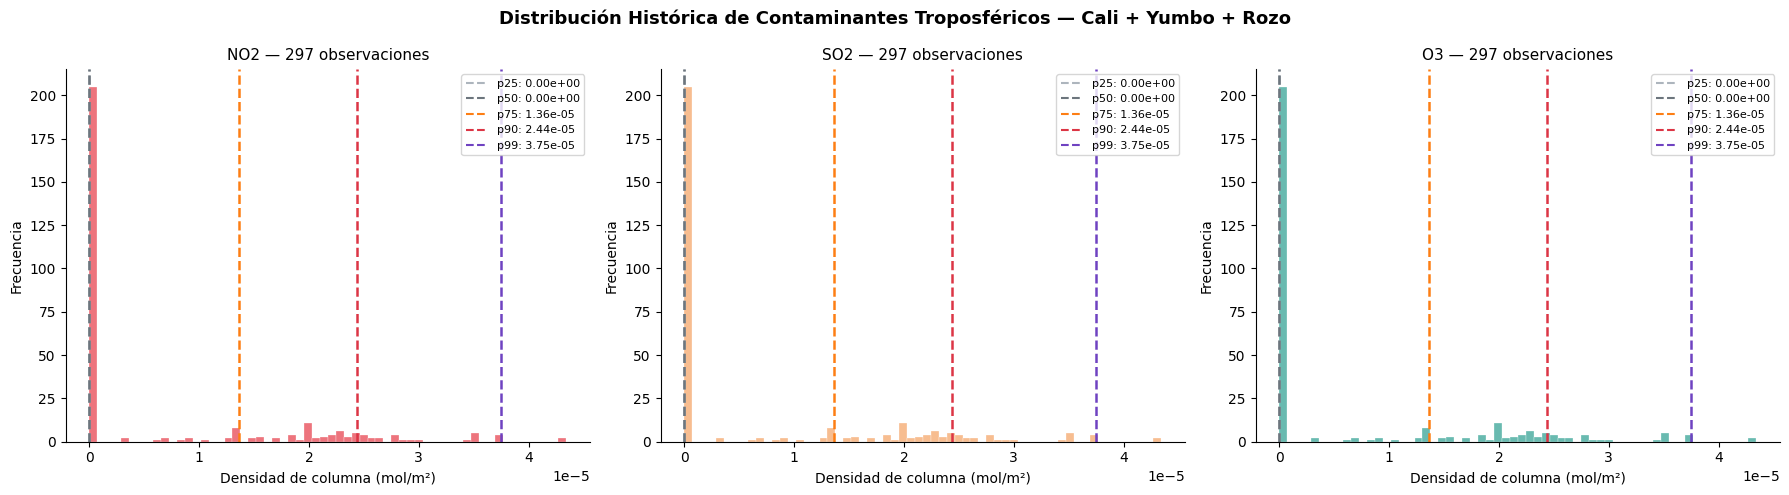

Gráfico guardado: histogramas_contaminantes_percentiles.png


In [42]:
COL_POLLUTANT_MAP = {
    "val_no2": ("NO2", "#e63946"),
    "val_so2": ("SO2", "#f4a261"),
    "val_o3" : ("O3",  "#2a9d8f"),
}
PCTL_COLORS = {25: "#adb5bd", 50: "#6c757d", 75: "#fd7e14", 90: "#dc3545", 99: "#6f42c1"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución Histórica de Contaminantes Troposféricos — Cali + Yumbo + Rozo",
             fontsize=13, fontweight="bold")

for ax, (col, (label, color)) in zip(axes, COL_POLLUTANT_MAP.items()):
    data = df_aligned[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue

    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)

    # Líneas de percentiles
    legend_handles = []
    for p, pc in PCTL_COLORS.items():
        if label in pctls and p in pctls[label]:
            v = pctls[label][p]
            ax.axvline(v, color=pc, linestyle="--", linewidth=1.8)
            legend_handles.append(
                mlines.Line2D([], [], color=pc, linestyle="--", label=f"p{p}: {v:.2e}")
            )

    ax.set_title(f"{label} — {len(data):,} observaciones", fontsize=11)
    ax.set_xlabel("Densidad de columna (mol/m²)")
    ax.set_ylabel("Frecuencia")
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right")
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("histogramas_contaminantes_percentiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: histogramas_contaminantes_percentiles.png")

## 8 · Generador de Descripciones Textuales en Ingles

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Spatial-Temporal Alignment
# Sentinel-2 ↔ Sentinel-5P
# English Multimodal Captions
# ─────────────────────────────────────────────────────────────────────────────

import re
import numpy as np
import pandas as pd

from scipy.spatial import cKDTree
from datetime import timedelta
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────
# Extract date from Sentinel-2 scene_id
# Example:
# S2B_18NUJ_20200127_0_L2A
# ─────────────────────────────────────────────────────────────

def extract_date_from_scene(scene_id):

    match = re.search(
        r"_(\d{8})_",
        scene_id
    )

    if match is None:

        return pd.NaT

    return pd.to_datetime(
        match.group(1),
        format="%Y%m%d"
    )


# ─────────────────────────────────────────────────────────────
# KDTree cache
# ─────────────────────────────────────────────────────────────

kdtree_cache = {}


# ─────────────────────────────────────────────────────────────
# Build KDTree by temporal window
# ─────────────────────────────────────────────────────────────

def build_kdtree_for_date(
    df_pollutant: pd.DataFrame,
    fecha
):
    """
    Build spatial KDTree for a pollutant
    using ±3 day temporal tolerance.
    """

    try:

        target_date = pd.to_datetime(fecha)

    except Exception:

        return None

    # cache key
    fecha_key = str(target_date.date())

    if fecha_key in kdtree_cache:

        return kdtree_cache[fecha_key]

    # ─────────────────────────────────────────────────────────
    # Temporal filtering
    # ─────────────────────────────────────────────────────────

    mask = (
        (df_pollutant["fecha"] >= target_date - timedelta(days=3)) &
        (df_pollutant["fecha"] <= target_date + timedelta(days=3))
    )

    subset = df_pollutant[mask]

    if len(subset) == 0:

        return None

    # ─────────────────────────────────────────────────────────
    # Spatial coordinates
    # KDTree uses [lat, lon]
    # ─────────────────────────────────────────────────────────

    coords = subset[["lat", "lon"]].values

    tree = cKDTree(coords)

    result = (
        tree,
        subset.reset_index(drop=True)
    )

    kdtree_cache[fecha_key] = result

    return result


# ─────────────────────────────────────────────────────────────
# Query nearest Sentinel-5P pixel
# ─────────────────────────────────────────────────────────────

def query_nearest(
    tree: cKDTree,
    subset: pd.DataFrame,
    lat: float,
    lon: float,
    max_dist_deg: float = 0.30
):
    """
    Search nearest Sentinel-5P pixel.

    max_dist_deg = 0.30 ≈ 33 km
    """

    dist, idx = tree.query(
        [lat, lon],
        k=1
    )

    if dist > max_dist_deg:

        return np.nan

    return float(
        subset.iloc[idx]["valor"]
    )


# ─────────────────────────────────────────────────────────────
# Semantic pollution categories
# ─────────────────────────────────────────────────────────────

def pollution_level(value):

    if np.isnan(value):

        return "unknown"

    if value < 1e-5:

        return "very low"

    elif value < 3e-5:

        return "low"

    elif value < 6e-5:

        return "moderate"

    elif value < 1e-4:

        return "high"

    else:

        return "very high"


# ─────────────────────────────────────────────────────────────
# Align Sentinel-2 tiles with Sentinel-5P
# ─────────────────────────────────────────────────────────────

aligned_records = []

for i in tqdm(
    range(N_TILES),
    desc="Aligning S2 ↔ S5P"
):

    fecha_i = extract_date_from_scene(
        escenas[i]
    )

    lat_c = centroid_lat[i]
    lon_c = centroid_lon[i]

    vals = {}

    # ─────────────────────────────────────────────────────────
    # Pollutant matching
    # ─────────────────────────────────────────────────────────

    for pollutant, df_p in s5p_dfs.items():

        result = build_kdtree_for_date(
            df_pollutant=df_p,
            fecha=fecha_i
        )

        if result is None:

            vals[pollutant] = np.nan

            continue

        tree, subset = result

        val = query_nearest(
            tree=tree,
            subset=subset,
            lat=lat_c,
            lon=lon_c,
            max_dist_deg=0.30
        )

        vals[pollutant] = val

    # ─────────────────────────────────────────────────────────
    # Semantic pollution levels
    # ─────────────────────────────────────────────────────────

    no2_level = pollution_level(
        vals.get("NO2", np.nan)
    )

    so2_level = pollution_level(
        vals.get("SO2", np.nan)
    )

    o3_level = pollution_level(
        vals.get("O3", np.nan)
    )

    # ─────────────────────────────────────────────────────────
    # English multimodal caption
    # ─────────────────────────────────────────────────────────

    caption_en = (
        f"Satellite image of Cali, Colombia, "
        f"with {no2_level} nitrogen dioxide pollution, "
        f"{so2_level} sulfur dioxide concentration, "
        f"and {o3_level} ozone levels."
    )

    # ─────────────────────────────────────────────────────────
    # Save aligned record
    # ─────────────────────────────────────────────────────────

    aligned_records.append({

        "idx_zarr": i,

        "scene_id": escenas[i],

        "date": fecha_i,

        "lat_centroid": lat_c,

        "lon_centroid": lon_c,

        "val_no2": vals.get("NO2", np.nan),

        "val_so2": vals.get("SO2", np.nan),

        "val_o3": vals.get("O3", np.nan),

        "caption_en": caption_en,
    })


# ─────────────────────────────────────────────────────────────
# Final dataframe
# ─────────────────────────────────────────────────────────────

df_aligned = pd.DataFrame(
    aligned_records
)

print("\nAlignment Summary:")

print(
    f"Aligned tiles: "
    f"{len(df_aligned):,} / {N_TILES:,}"
)

print("\nNaN ratio:")

print(
    df_aligned[
        ["val_no2", "val_so2", "val_o3"]
    ].isna().mean()
)

print("\nExamples:")

display(
    df_aligned[
        [
            "scene_id",
            "date",
            "val_no2",
            "val_so2",
            "val_o3",
            "caption_en"
        ]
    ].head(10)
)

Aligning S2 ↔ S5P: 100%|██████████| 363/363 [00:05<00:00, 66.74it/s] 


Alignment Summary:
Aligned tiles: 363 / 363

NaN ratio:
val_no2    0.181818
val_so2    0.181818
val_o3     0.181818
dtype: float64

Examples:


,scene_id,date,val_no2,val_so2,val_o3,caption_en
0,S2B_18NUJ_20200127_0_L2A,2020-01-27,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
1,S2B_18NUJ_20200127_1_L2A,2020-01-27,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
2,S2B_18NUK_20200127_0_L2A,2020-01-27,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
3,S2B_18NUJ_20200117_0_L2A,2020-01-17,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
4,S2B_18NUJ_20200117_1_L2A,2020-01-17,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
5,S2B_18NUK_20200117_1_L2A,2020-01-17,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
6,S2B_18NUK_20200117_0_L2A,2020-01-17,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
7,S2A_18NUJ_20200112_1_L2A,2020-01-12,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
8,S2A_18NUJ_20200112_0_L2A,2020-01-12,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
9,S2A_18NUK_20200112_0_L2A,2020-01-12,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."


## 9 · Exportar Dataset Multimodal (≥1000 pares)

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# Export multimodal dataset
# JSONL + CSV
# ─────────────────────────────────────────────────────────────────────────────

import json
import numpy as np

from pathlib import Path


# ─────────────────────────────────────────────────────────────
# Output paths
# ─────────────────────────────────────────────────────────────

OUTPUT_JSONL = Path(
    r"D:\analitica\dataset_multimodal_en.jsonl"
)


# ─────────────────────────────────────────────────────────────
# Build local Zarr reference
# ─────────────────────────────────────────────────────────────

def zarr_index_to_path(idx: int) -> str:

    return f"{ZARR_PATH}[{idx}]"


# ─────────────────────────────────────────────────────────────
# Prepare export dataframe
# ─────────────────────────────────────────────────────────────

df_export = df_aligned.rename(columns={

    "idx_zarr": "tile_id",

    "lat_centroid": "lat_centroid",

    "lon_centroid": "lon_centroid",

}).copy()


# local image reference
df_export["zarr_reference"] = df_export[
    "tile_id"
].apply(
    zarr_index_to_path
)


# ─────────────────────────────────────────────────────────────
# Columns to export
# ─────────────────────────────────────────────────────────────

COLS_EXPORT = [

    "tile_id",

    "zarr_reference",

    "scene_id",

    "date",

    "lat_centroid",

    "lon_centroid",

    "val_no2",

    "val_so2",

    "val_o3",

    "caption_en",
]


# final dataframe
df_final = df_export[
    COLS_EXPORT
].copy()


# ─────────────────────────────────────────────────────────────
# Basic validation
# ─────────────────────────────────────────────────────────────

print("\nDataset summary:")

print(
    f"Total image-text pairs: "
    f"{len(df_final):,}"
)

print(
    f"Columns: {COLS_EXPORT}"
)


# ─────────────────────────────────────────────────────────────
# Export JSONL
# ─────────────────────────────────────────────────────────────

with open(
    OUTPUT_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for _, row in df_final.iterrows():

        record = row.to_dict()

        # Convert NaN → null
        record = {

            k: (
                None
                if (
                    isinstance(v, float)
                    and np.isnan(v)
                )
                else v
            )

            for k, v in record.items()
        }

        # datetime serialization
        if isinstance(record["date"], pd.Timestamp):

            record["date"] = str(
                record["date"].date()
            )

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            ) + "\n"
        )


print(
    f"\n✅ JSONL exported: "
    f"{OUTPUT_JSONL}"
)


# ─────────────────────────────────────────────────────────────
# Export CSV backup
# ─────────────────────────────────────────────────────────────

csv_path = OUTPUT_JSONL.with_suffix(
    ".csv"
)

df_final.to_csv(

    csv_path,

    index=False,

    encoding="utf-8"
)

print(
    f"✅ CSV backup exported: "
    f"{csv_path}"
)


# ─────────────────────────────────────────────────────────────
# Preview
# ─────────────────────────────────────────────────────────────

display(
    df_final.head()
)


Dataset summary:
Total image-text pairs: 363
Columns: ['tile_id', 'zarr_reference', 'scene_id', 'date', 'lat_centroid', 'lon_centroid', 'val_no2', 'val_so2', 'val_o3', 'caption_en']

✅ JSONL exported: D:\analitica\dataset_multimodal_en.jsonl
✅ CSV backup exported: D:\analitica\dataset_multimodal_en.csv


,tile_id,zarr_reference,scene_id,date,lat_centroid,lon_centroid,val_no2,val_so2,val_o3,caption_en
0,0,D:\analitica\procesado_zarr\sentinel2_224.zarr[0],S2B_18NUJ_20200127_0_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
1,1,D:\analitica\procesado_zarr\sentinel2_224.zarr[1],S2B_18NUJ_20200127_1_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
2,2,D:\analitica\procesado_zarr\sentinel2_224.zarr[2],S2B_18NUK_20200127_0_L2A,2020-01-27,3.121543,-76.305557,0.000025,0.000025,0.000025,"Satellite image of Cali, Colombia, with low ni..."
3,3,D:\analitica\procesado_zarr\sentinel2_224.zarr[3],S2B_18NUJ_20200117_0_L2A,2020-01-17,3.121543,-76.305557,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."
4,4,D:\analitica\procesado_zarr\sentinel2_224.zarr[4],S2B_18NUJ_20200117_1_L2A,2020-01-17,3.121543,-76.305557,0.000000,0.000000,0.000000,"Satellite image of Cali, Colombia, with very l..."


## 10 · Resumen Final y MD5 del Dataset

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# Final Dataset Summary + MD5
# ─────────────────────────────────────────────────────────────────────────────

import json
import hashlib

from pathlib import Path


# ─────────────────────────────────────────────────────────────
# MD5 helper
# ─────────────────────────────────────────────────────────────

def md5_file(path: Path) -> str:

    h = hashlib.md5()

    with open(path, "rb") as f:

        for chunk in iter(lambda: f.read(1 << 20), b""):

            h.update(chunk)

    return h.hexdigest()


# ─────────────────────────────────────────────────────────────
# Dataset summary
# ─────────────────────────────────────────────────────────────

summary = {

    "dataset_path": str(OUTPUT_JSONL),

    "dataset_csv": str(csv_path),

    "n_pairs": len(df_final),

    "date_start": str(df_final["date"].min()),

    "date_end": str(df_final["date"].max()),

    "bbox_cali": CALI_BBOX,

    "variables": [
        "val_no2",
        "val_so2",
        "val_o3"
    ],

    "nan_fraction": {

        "no2": float(df_final["val_no2"].isna().mean()),

        "so2": float(df_final["val_so2"].isna().mean()),

        "o3": float(df_final["val_o3"].isna().mean()),
    },

    "md5_jsonl": md5_file(OUTPUT_JSONL),

    "md5_csv": md5_file(csv_path),
}


# ─────────────────────────────────────────────────────────────
# Export summary JSON
# ─────────────────────────────────────────────────────────────

SUMMARY_PATH = Path(
    r"D:\analitica\s5p_alignment_summary.json"
)

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


# ─────────────────────────────────────────────────────────────
# Print summary
# ─────────────────────────────────────────────────────────────

print("── Final Multimodal Dataset Summary ─────────────────────")

print(
    json.dumps(
        summary,
        indent=2,
        ensure_ascii=False
    )
)


── Final Multimodal Dataset Summary ─────────────────────
{
  "dataset_path": "D:\\analitica\\dataset_multimodal_en.jsonl",
  "dataset_csv": "D:\\analitica\\dataset_multimodal_en.csv",
  "n_pairs": 363,
  "date_start": "2020-01-02 00:00:00",
  "date_end": "2026-04-30 00:00:00",
  "bbox_cali": {
    "lon_min": -76.65,
    "lat_min": 3.25,
    "lon_max": -76.35,
    "lat_max": 3.65
  },
  "variables": [
    "val_no2",
    "val_so2",
    "val_o3"
  ],
  "nan_fraction": {
    "no2": 0.18181818181818182,
    "so2": 0.18181818181818182,
    "o3": 0.18181818181818182
  },
  "md5_jsonl": "cd6ece0a0fb6654502243b4dab5105b3",
  "md5_csv": "d476cc39ea9422bbbdaf7b012d120b8e"
}
